In [1]:
import logging
from nlab_modbus.manager import DeviceManager
import time
import matplotlib.pyplot as plt


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    force=True
)
logging.getLogger("pymodbus").setLevel(logging.CRITICAL)
logging.getLogger("pymodbus.logging").setLevel(logging.CRITICAL)


In [2]:
mgr = DeviceManager()

In [3]:
ips = await mgr.scan_remote_ips_async()
print(ips)

['192.168.10.134', '192.168.10.128']


In [4]:
mgr.scan_local_ports()

2026-05-29 14:55:28,246 | INFO     | nlab_modbus.discovery.scan | Register found: 257


In [5]:
mgr.local

In [6]:
mgr.local[0].connection_info()

'serial://COM6:1'

In [7]:
mgr.local[0].get_board_temp()

30.76

In [8]:
for ip in ips:
    mgr.scan_remote(ip, [5001, 5002])

2026-05-29 14:55:32,243 | INFO     | nlab_modbus.discovery.scan | Register found: 769
2026-05-29 14:55:34,447 | INFO     | nlab_modbus.discovery.scan | Register found: 257
2026-05-29 14:55:34,531 | INFO     | nlab_modbus.discovery.scan | Register found: 513


In [9]:
mgr.remote

In [10]:
mgr.remote[0].set_pwm_enable(1)

In [11]:
mgr.all_devices

In [12]:
mgr.close_all()

In [13]:
mgr.local[0].connect()

In [14]:
temps = []
counts = []
times = []
t0 = time.monotonic()
dt = 0.22
next_time = t0 + dt  # Absolute target for first
while next_time - t0 < 15:
    temp = mgr.local[0].get_board_temp()
    cps = mgr.remote[2].get_pulses_per_sec()
    temps.append(temp)
    counts.append(cps)
    times.append(time.monotonic() - t0)
    print(f"{times[-1]:8.2f} s, {temp:7.2f} °C, {cps:6d} cps", end="\r")
    next_time += dt
    sleep_dur = next_time - time.monotonic()
    if sleep_dur > 0:
        time.sleep(sleep_dur)

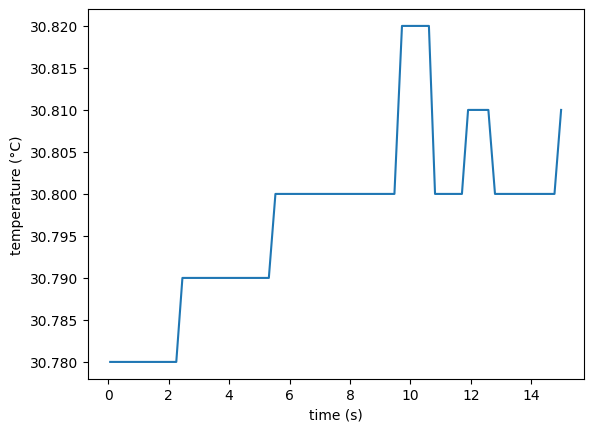

In [15]:
plt.figure()
plt.plot(times, temps)
plt.xlabel('time (s)')
plt.ylabel('temperature (°C)')
plt.show()

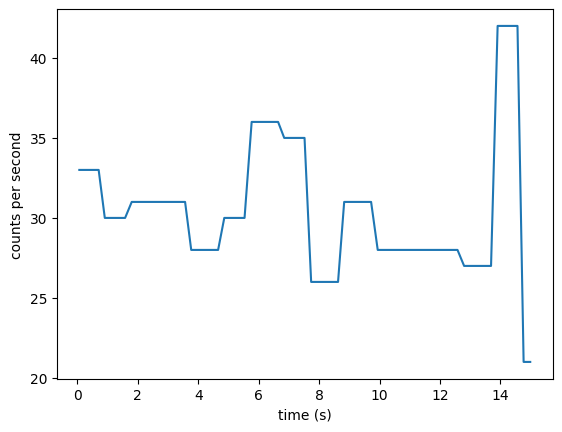

In [16]:
plt.figure()
plt.plot(times, counts)
plt.xlabel('time (s)')
plt.ylabel('counts per second')
plt.show()

In [17]:
import numpy as np

In [18]:
np.array(times[1:]) - np.array(times[:-1])

array([0.406, 0.234, 0.203, 0.219, 0.219, 0.234, 0.219, 0.219, 0.234,
       0.203, 0.235, 0.203, 0.219, 0.218, 0.235, 0.203, 0.219, 0.234,
       0.203, 0.234, 0.204, 0.234, 0.219, 0.218, 0.235, 0.203, 0.234,
       0.203, 0.235, 0.203, 0.219, 0.218, 0.235, 0.219, 0.218, 0.235,
       0.203, 0.234, 0.203, 0.219, 0.234, 0.188, 0.25 , 0.219, 0.234,
       0.203, 0.235, 0.203, 0.218, 0.219, 0.219, 0.234, 0.203, 0.235,
       0.203, 0.234, 0.219, 0.219, 0.234, 0.188, 0.25 , 0.218, 0.204,
       0.218, 0.235, 0.203, 0.219])

(array([ 2.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 15.,  2.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  7., 16.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0., 22.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.188     , 0.18970312, 0.19140625, 0.19310937, 0.1948125 ,
        0.19651562, 0.19821875, 0.19992187, 0.201625  , 0.20332812,
        0.20503125, 0.20673437, 0.2084375 , 0.21014062, 0.21184375,
        0.21354687, 0.21525   , 0.21695312, 0.21865625, 0.22035937,
      

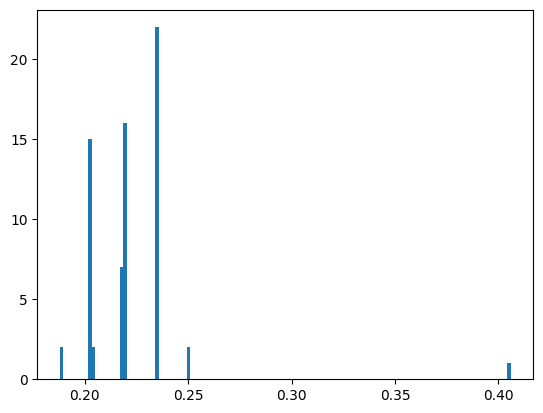

In [19]:
plt.hist(np.array(times[1:]) - np.array(times[:-1]), bins=128)

In [20]:
mgr.local[0]

In [21]:
result = mgr.local[0].read_snapshot()

In [22]:
print(result)

{'sipm_voltage_10mv': 0.31, 'sipm_current_ua': 0.0, 'board_temp_adc': 30.16, 'usb_rx_frames_cnt': 8886.0, 'usb_rx_crc_err_cnt': 5.0, 'usb_rx_bad_req_cnt': 8.0, 'cpu_temp': 34.0, 'board_temp': 30.810000000000002, 'eeprom_error': 0.0, 'supply_voltage': 4.91, 'adc_sipm_vout': 0.4, 'sipm_board_temp': 355.36, 'sipm_correct_voltage_mv': 0.0, 'vout_supply_fault': 0.0, 'ext_amp_supply_fault': 0.0, 'led_drv_temp': 32.0, 'led_drv_status': 0.0, 'vout_ripple': 6.0, 'pid_saturation': 0.0}


In [23]:
from nlab_modbus.core.register_specs import RegisterType
from nlab_modbus.devices.sipm import SiPMDevice

In [24]:
mgr.local[0]._register_index[(RegisterType.HOLDING, 3)]

('vout_set',
 RegisterSpec(reg_type=<RegisterType.HOLDING: 'holding'>, address=3, dtype='uint16', min=1500, max=7800, count=1, scale=0.01, unit='mV'))

In [25]:
count = SiPMDevice.READOUT_STOP - SiPMDevice.READOUT_START

In [26]:
count

19

In [27]:
registers = mgr.local[0].read_raw_block(address=SiPMDevice.READOUT_START, count=count)

In [28]:
registers

[31, 0, 3016, 8887, 5, 8, 34, 3081, 0, 491, 40, 35536, 0, 0, 0, 31, 0, 6, 0]

In [29]:
test = mgr.local[0].client.read_input_registers(
            address=SiPMDevice.READOUT_START,
            count=count,
            device_id=mgr.local[0].device_id,
        )

In [30]:
test

In [31]:
test.registers

[31, 0, 3016, 8888, 5, 8, 34, 3081, 0, 489, 40, 35536, 0, 0, 0, 31, 0, 6, 0]

In [47]:
result = mgr.local[0].read_snapshot()
for key, value in result.items():
    print(key, value)

sipm_voltage_10mv 0.31
sipm_current_ua 0.0
board_temp_adc 30.43
usb_rx_frames_cnt 8903.0
usb_rx_crc_err_cnt 5.0
usb_rx_bad_req_cnt 8.0
cpu_temp 34.0
board_temp 31.04
eeprom_error 0.0
supply_voltage 4.92
adc_sipm_vout 0.26
sipm_board_temp 31.830000000000002
sipm_correct_voltage_mv 0.0
vout_supply_fault 0.0
ext_amp_supply_fault 0.0
led_drv_temp 32.0
led_drv_status 0.0
vout_ripple 6.0
pid_saturation 0.0


In [55]:
labels = list(mgr.local[0].read_snapshot().keys())

In [56]:
print(labels)

['sipm_voltage_10mv', 'sipm_current_ua', 'board_temp_adc', 'usb_rx_frames_cnt', 'usb_rx_crc_err_cnt', 'usb_rx_bad_req_cnt', 'cpu_temp', 'board_temp', 'eeprom_error', 'supply_voltage', 'adc_sipm_vout', 'sipm_board_temp', 'sipm_correct_voltage_mv', 'vout_supply_fault', 'ext_amp_supply_fault', 'led_drv_temp', 'led_drv_status', 'vout_ripple', 'pid_saturation']


In [61]:
buffer = {lbl: [] for lbl in labels}
times = []
t0 = time.monotonic()
dt = 0.22
next_time = t0 + dt  # Absolute target for first
time_limit = 600
while next_time - t0 < time_limit:
    stats = mgr.local[0].read_snapshot()
    for key, value in stats.items():
        buffer[key].append(value)
    times.append(time.monotonic() - t0)
    print(f"{times[-1]:8.2f} s, measuring for {time_limit:8.2f}", end='\r')
    next_time += dt
    sleep_dur = next_time - time.monotonic()
    if sleep_dur > 0:
        time.sleep(sleep_dur)

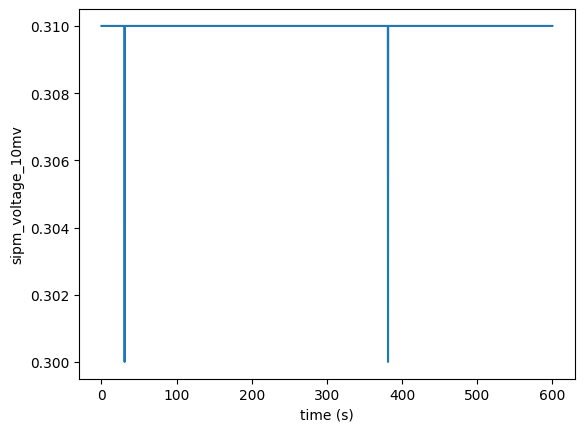

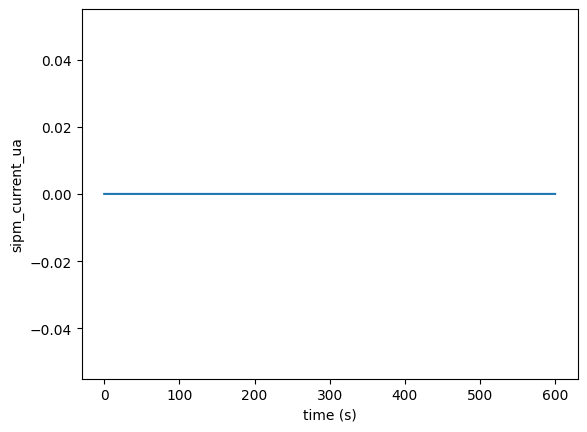

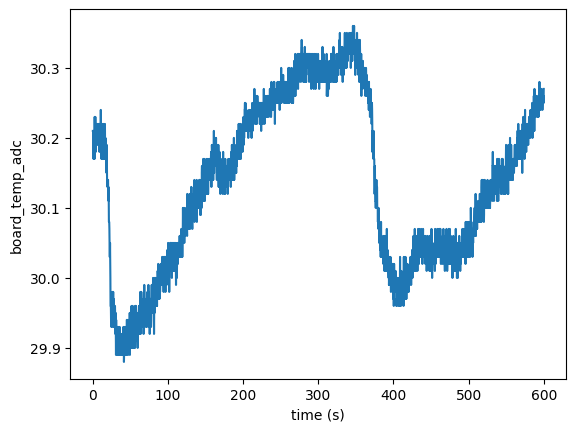

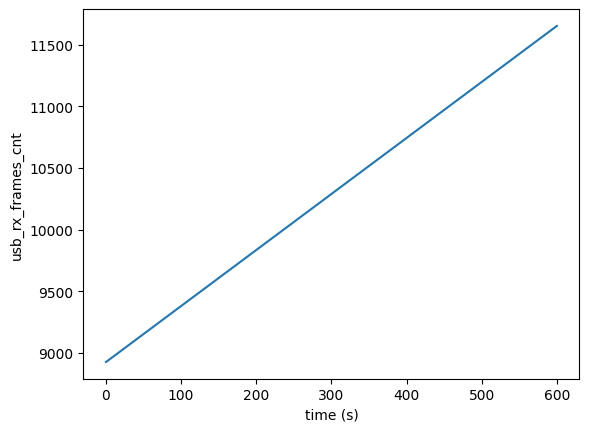

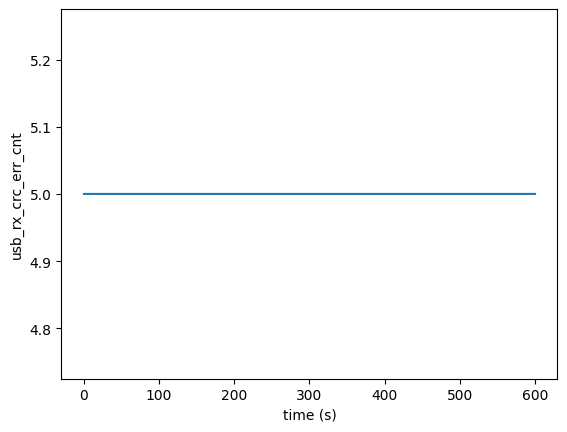

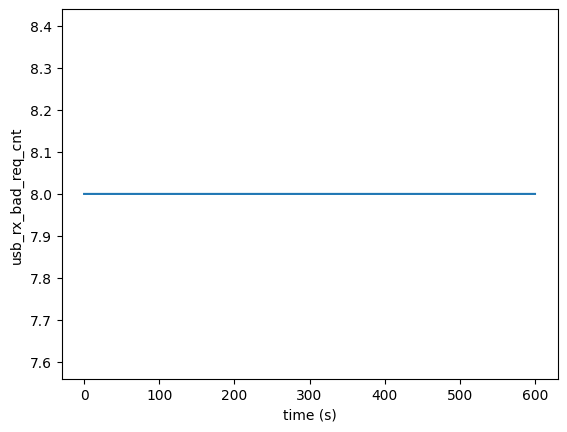

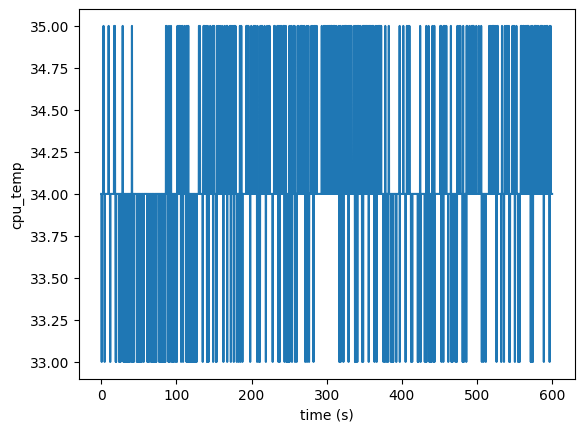

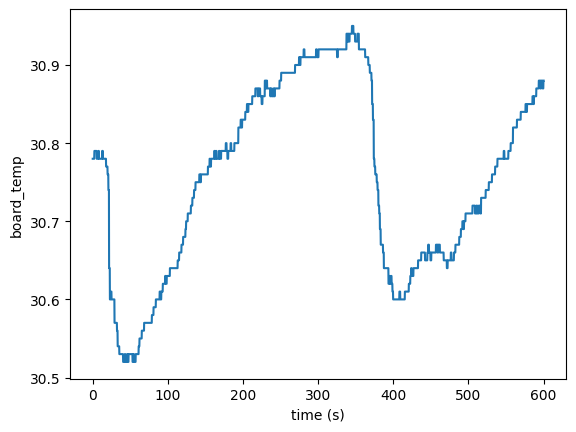

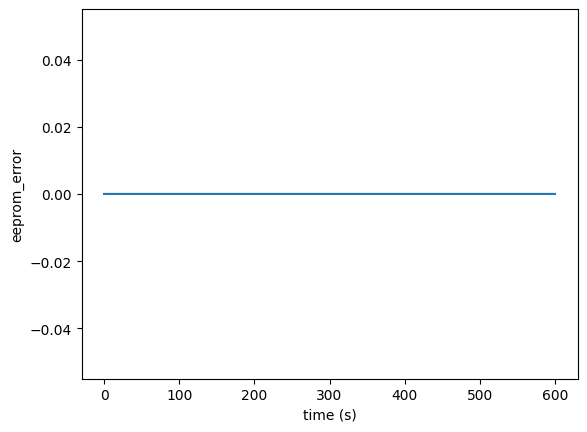

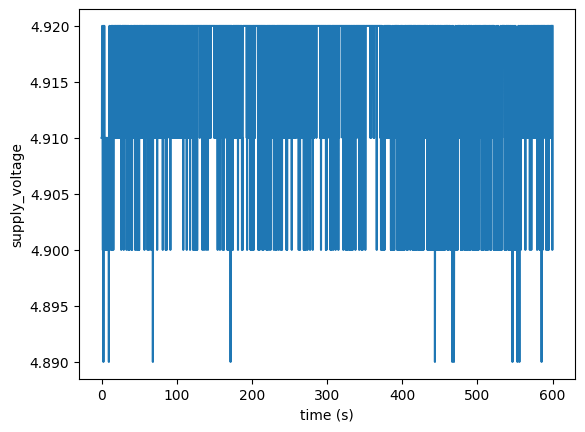

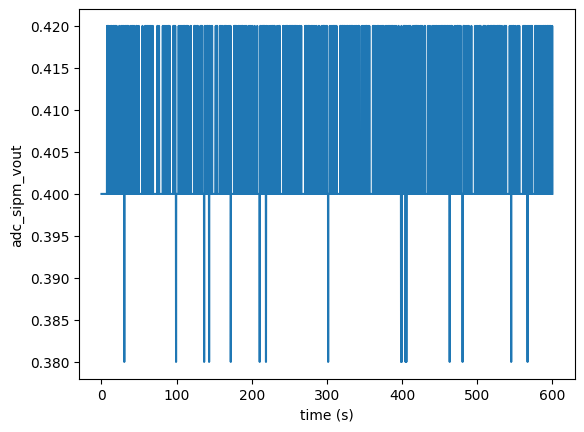

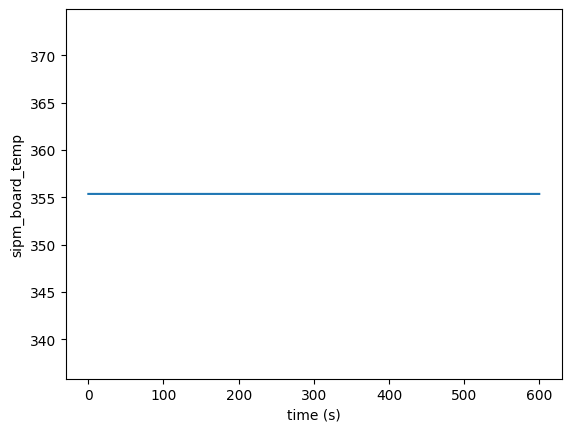

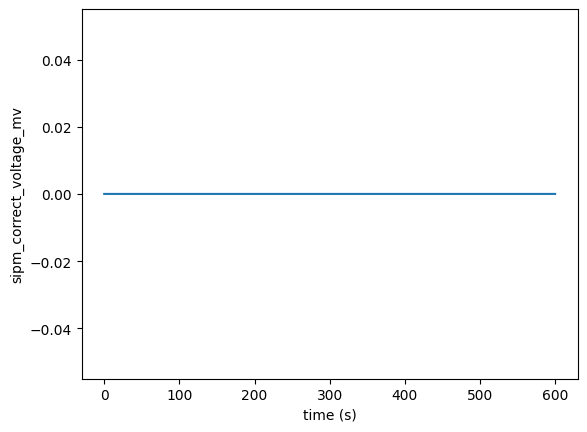

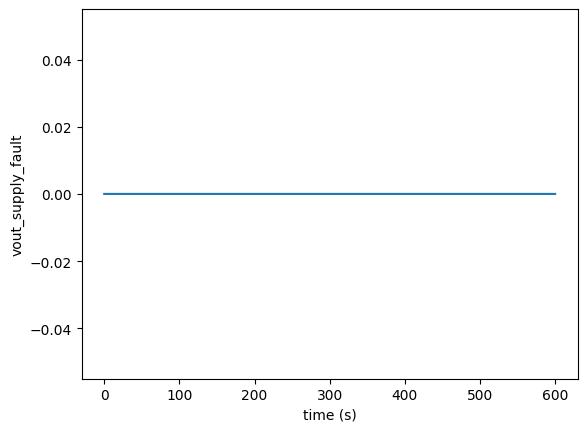

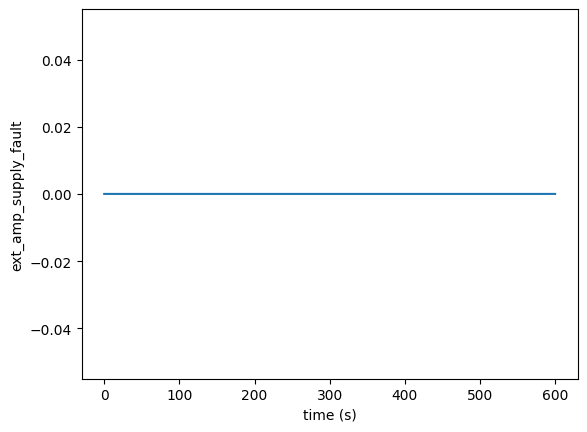

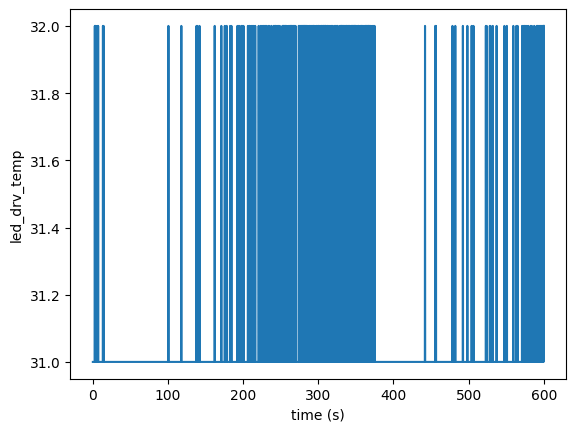

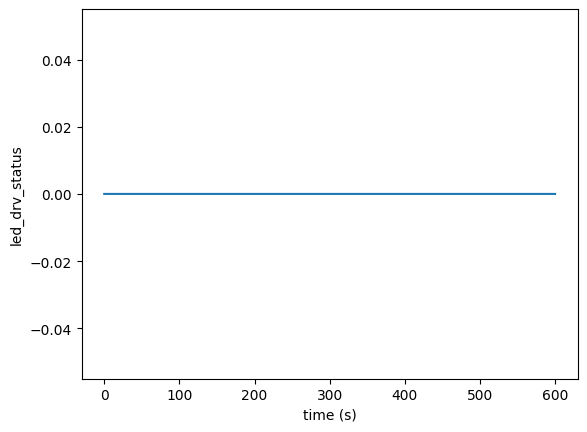

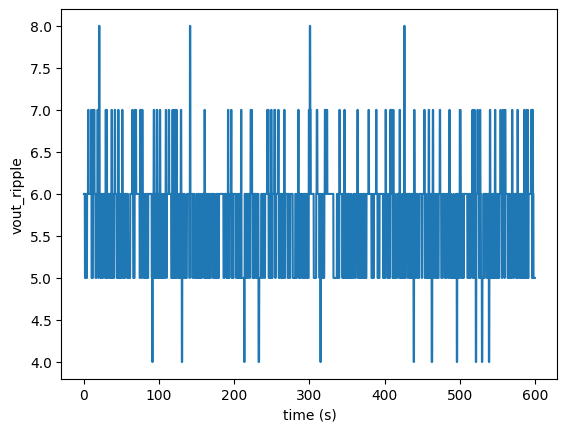

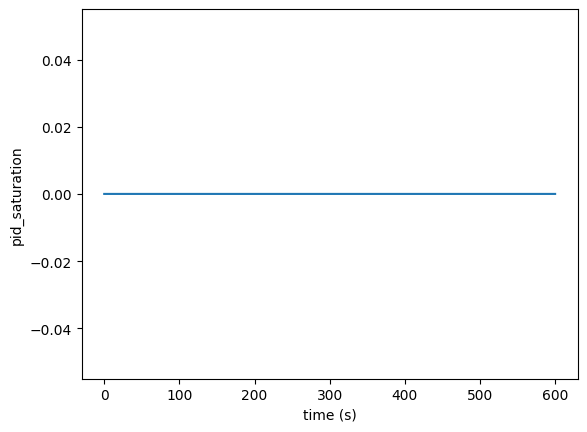

In [ ]:
for key, values in buffer.items():
    plt.figure()
    plt.plot(times, values)
    plt.xlabel('time (s)')
    plt.ylabel(key)
    plt.show()

In [64]:
dt = np.array(times[1:]) - np.array(times[:-1])

(array([794.,   0.,   0., 237., 754.,   0.,   0., 551., 316.,   0.,   0.,
          0.,  73.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([0.203     , 0.20690625, 0.2108125 , 0.21471875, 0.218625  ,
        0.22253125, 0.2264375 , 0.23034375, 0.23425   , 0.23815625,
        0.2420625 , 0.24596875, 0.249875  , 0.25378125, 0.2576875 ,
        0.26159375, 0.2655    , 0.26940625, 0.2733125 , 0.27721875,
        0.281125  , 0.28503125, 0.2889375 , 0.29284375, 0.29675   ,
        0.30065625, 0.3045625 , 0.30846875, 0.312375  , 0.31628125,
        0.3201875 , 0.32409375, 0.328     , 0.33190625, 0.3358125 ,
        0.33971875, 0.343625  , 0.34753125, 0.3514375 , 0.35534375,
        0.35925   , 0.

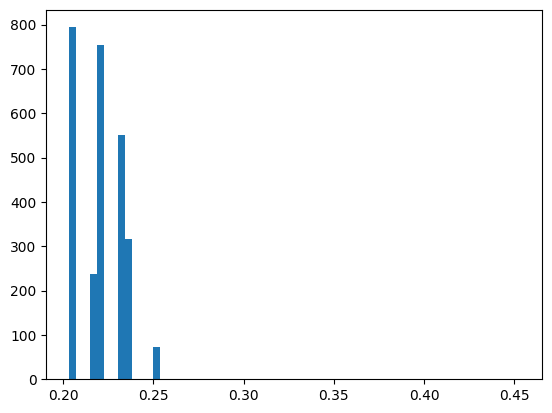

In [65]:
plt.hist(dt, bins=64)

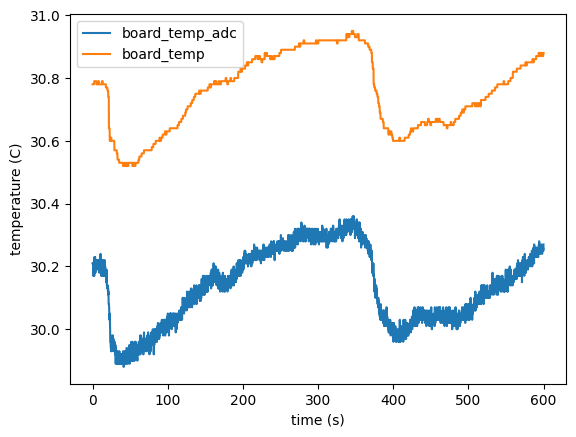

In [72]:
plt.figure()
for key, values in buffer.items():
    if 'board_temp' in key and 'sipm' not in key:
        plt.plot(times, np.array(values), label=key)
plt.xlabel('time (s)')
plt.ylabel('temperature (C)')
plt.legend()
plt.show()